In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt 
from tqdm.notebook import tqdm


In [3]:
ds = pd.read_csv("/fs2/toby/CmP/data/processed/cams_daily_district_2025.csv")
ds

,date,district,pm25,pm10,no2,o3,so2,no,co,nh3,...,nh3_lag5,nh3_lag6,nh3_lag7,dust_lag1,dust_lag2,dust_lag3,dust_lag4,dust_lag5,dust_lag6,dust_lag7
0,2025-01-01,Charlottenburg-Wilmersdorf,8.402450,10.911201,7.173550,55.977757,1.529468,0.221353,164.517868,0.492240,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,Friedrichshain-Kreuzberg,8.459352,10.878231,7.839928,55.596455,1.545138,0.211034,167.664825,0.517329,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01,Lichtenberg,8.556941,10.695080,7.531908,55.700726,1.550990,0.177792,168.912033,0.503018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-01,Marzahn-Hellersdorf,8.587070,10.544561,6.712381,56.119091,1.306089,0.127910,169.993225,0.454229,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-01,Mitte,8.402450,10.911201,7.173550,55.977757,1.529468,0.221353,164.517868,0.492240,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4375,2025-12-31,Reinickendorf,7.159323,10.095371,10.826286,55.099583,1.160943,0.279106,180.912949,1.082377,...,3.391076,2.036139,0.855643,0.010466,0.035160,0.031143,0.230558,0.098233,0.038996,0.042058
4376,2025-12-31,Spandau,6.837599,9.670142,8.302455,56.681137,0.997308,0.188678,173.671768,0.890730,...,2.572194,2.194589,0.880890,0.010473,0.034466,0.031344,0.228794,0.083972,0.038829,0.043074
4377,2025-12-31,Steglitz-Zehlendorf,6.570660,9.412089,7.858526,57.559235,0.956699,0.174279,173.563843,0.900949,...,2.696046,2.145082,1.086675,0.010599,0.035157,0.031734,0.231155,0.087923,0.043404,0.039825
4378,2025-12-31,Tempelhof-Schöneberg,7.072755,10.037616,10.384637,56.195324,1.260381,0.286408,180.317276,1.143963,...,4.219896,2.007176,1.038005,0.010576,0.034457,0.031506,0.235337,0.094815,0.043184,0.040034


In [4]:
district = pd.read_csv("/fs2/toby/CmP/data/processed/daily_district_health_smoothed.csv")

In [5]:
## Select data from 2015-01-01 to 2025-12-31
district = district[(district['date'] >= '2015-01-01') & (district['date'] <= '2025-12-31')]

In [6]:
## Join datasets on date and district
merged = pd.merge(district, ds, on=['date', 'district'], how='inner')
merged

,date,district,code_02_allergy_insect,code_06_breathing,code_09_cardiac_arrest,code_10_chest_pain,code_12_seizure,code_13_blood_sugar,code_17_falls,code_18_headache,...,nh3_lag5,nh3_lag6,nh3_lag7,dust_lag1,dust_lag2,dust_lag3,dust_lag4,dust_lag5,dust_lag6,dust_lag7
0,2025-01-01,Charlottenburg-Wilmersdorf,0.428571,15.142857,1.857143,7.428571,3.142857,0.571429,23.142857,0.142857,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,Friedrichshain-Kreuzberg,0.285714,9.857143,0.571429,6.285714,1.285714,1.000000,8.857143,0.571429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01,Lichtenberg,0.000000,12.428571,1.285714,8.428571,0.857143,0.857143,15.428571,0.857143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-01,Marzahn-Hellersdorf,0.857143,9.571429,1.571429,6.571429,2.428571,1.000000,14.285714,0.285714,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-01,Mitte,0.571429,15.000000,1.571429,9.142857,2.285714,0.714286,18.714286,0.571429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4375,2025-12-31,Reinickendorf,0.428571,13.714286,1.142857,9.142857,1.571429,1.285714,15.857143,0.714286,...,3.391076,2.036139,0.855643,0.010466,0.035160,0.031143,0.230558,0.098233,0.038996,0.042058
4376,2025-12-31,Spandau,0.857143,15.285714,1.142857,6.857143,1.714286,0.714286,15.428571,0.714286,...,2.572194,2.194589,0.880890,0.010473,0.034466,0.031344,0.228794,0.083972,0.038829,0.043074
4377,2025-12-31,Steglitz-Zehlendorf,0.857143,13.571429,2.285714,5.714286,1.857143,0.714286,20.714286,0.428571,...,2.696046,2.145082,1.086675,0.010599,0.035157,0.031734,0.231155,0.087923,0.043404,0.039825
4378,2025-12-31,Tempelhof-Schöneberg,0.571429,17.285714,1.142857,7.857143,2.428571,0.428571,18.285714,1.285714,...,4.219896,2.007176,1.038005,0.010576,0.034457,0.031506,0.235337,0.094815,0.043184,0.040034


In [7]:
## Correlation analysis between features and health outcomes district wise
merged_df = merged.drop(columns=['date', 'district','month', 'year','day_of_year','week_of_year',
                                'is_public_holiday','covid_flag','doy_sin','doy_cos',])

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

corr =merged_df.corr()


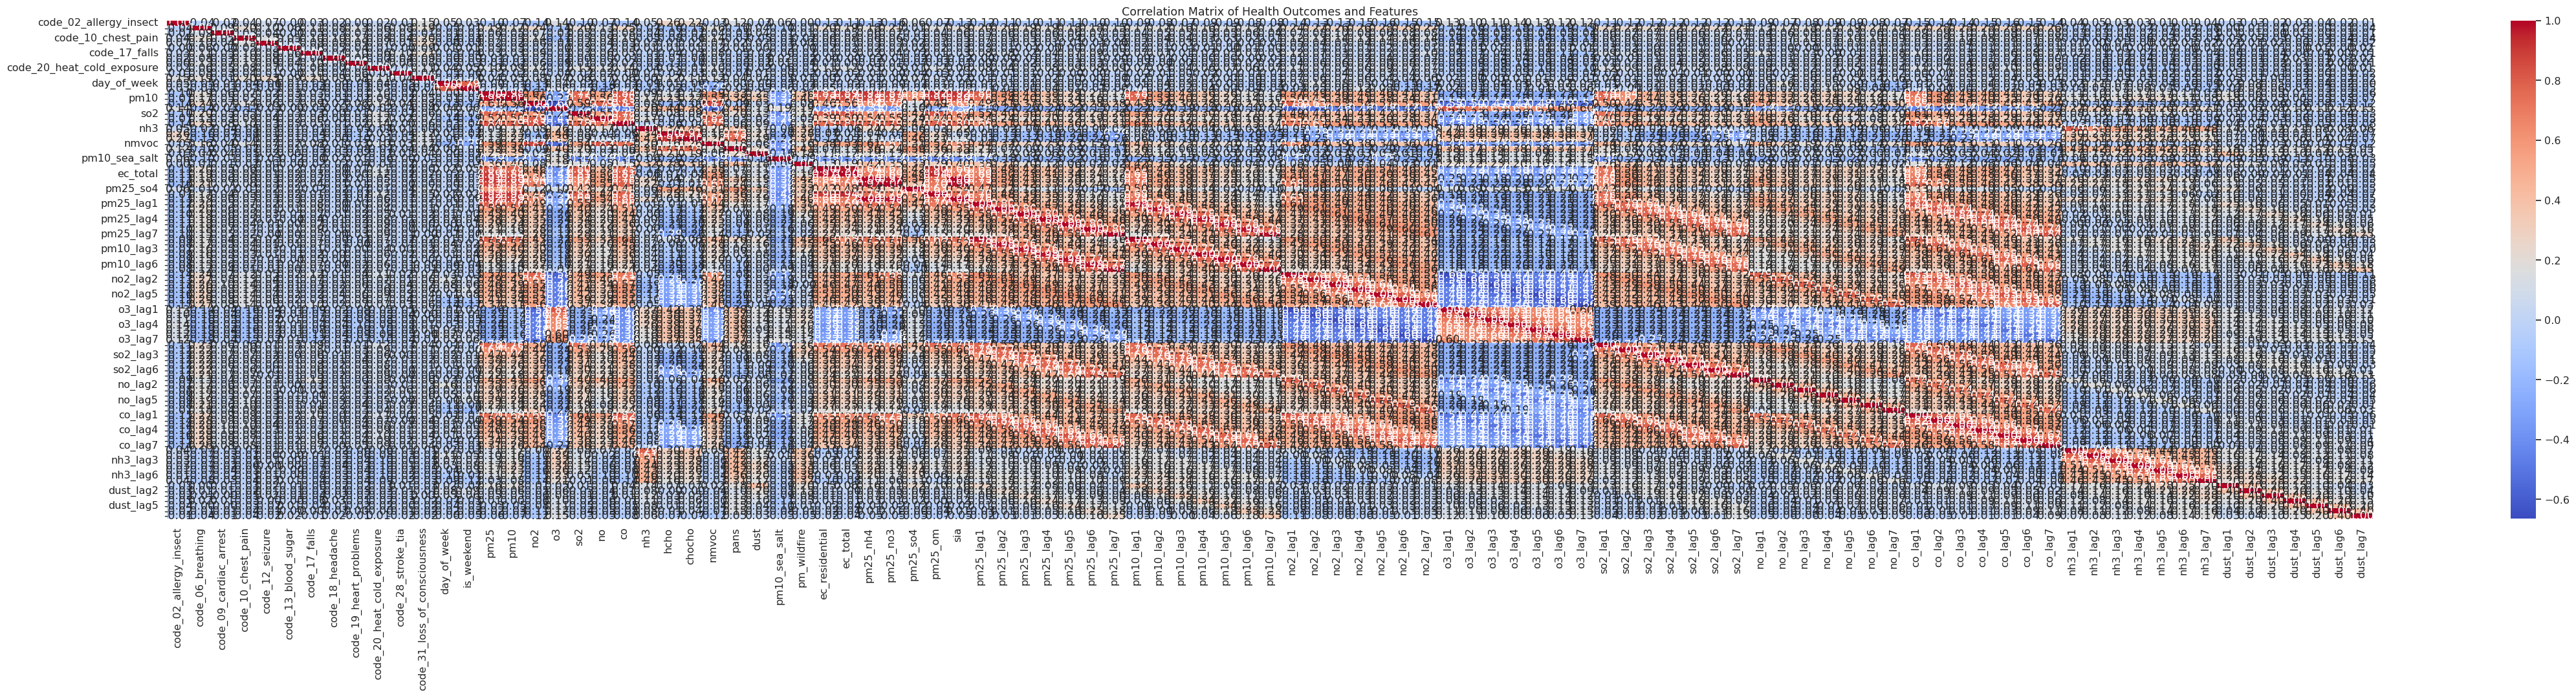

In [23]:

## Visualize correlation matrix
plt.figure(figsize=(55, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Health Outcomes and Features")
plt.show()

In [9]:
## Checking the highest correlation of CAMs features towards health-issues
health_issues =['code_02_allergy_insect',
 'code_06_breathing',
 'code_09_cardiac_arrest',
 'code_10_chest_pain',
 'code_12_seizure',
#  'code_13_blood_sugar',
#  'code_17_falls',
 'code_18_headache',
 'code_19_heart_problems',
 'code_20_heat_cold_exposure',
 'code_28_stroke_tia',
 'code_31_loss_of_consciousness']

cams_features = ds.columns.tolist()[2:]

correlation_results = {}
for health_issue in health_issues:
    correlations = merged_df[cams_features].corrwith(merged_df[health_issue])
    correlation_results[health_issue] = correlations.abs().sort_values(ascending=False)


/tmp/ipykernel_1576144/2783129466.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd")


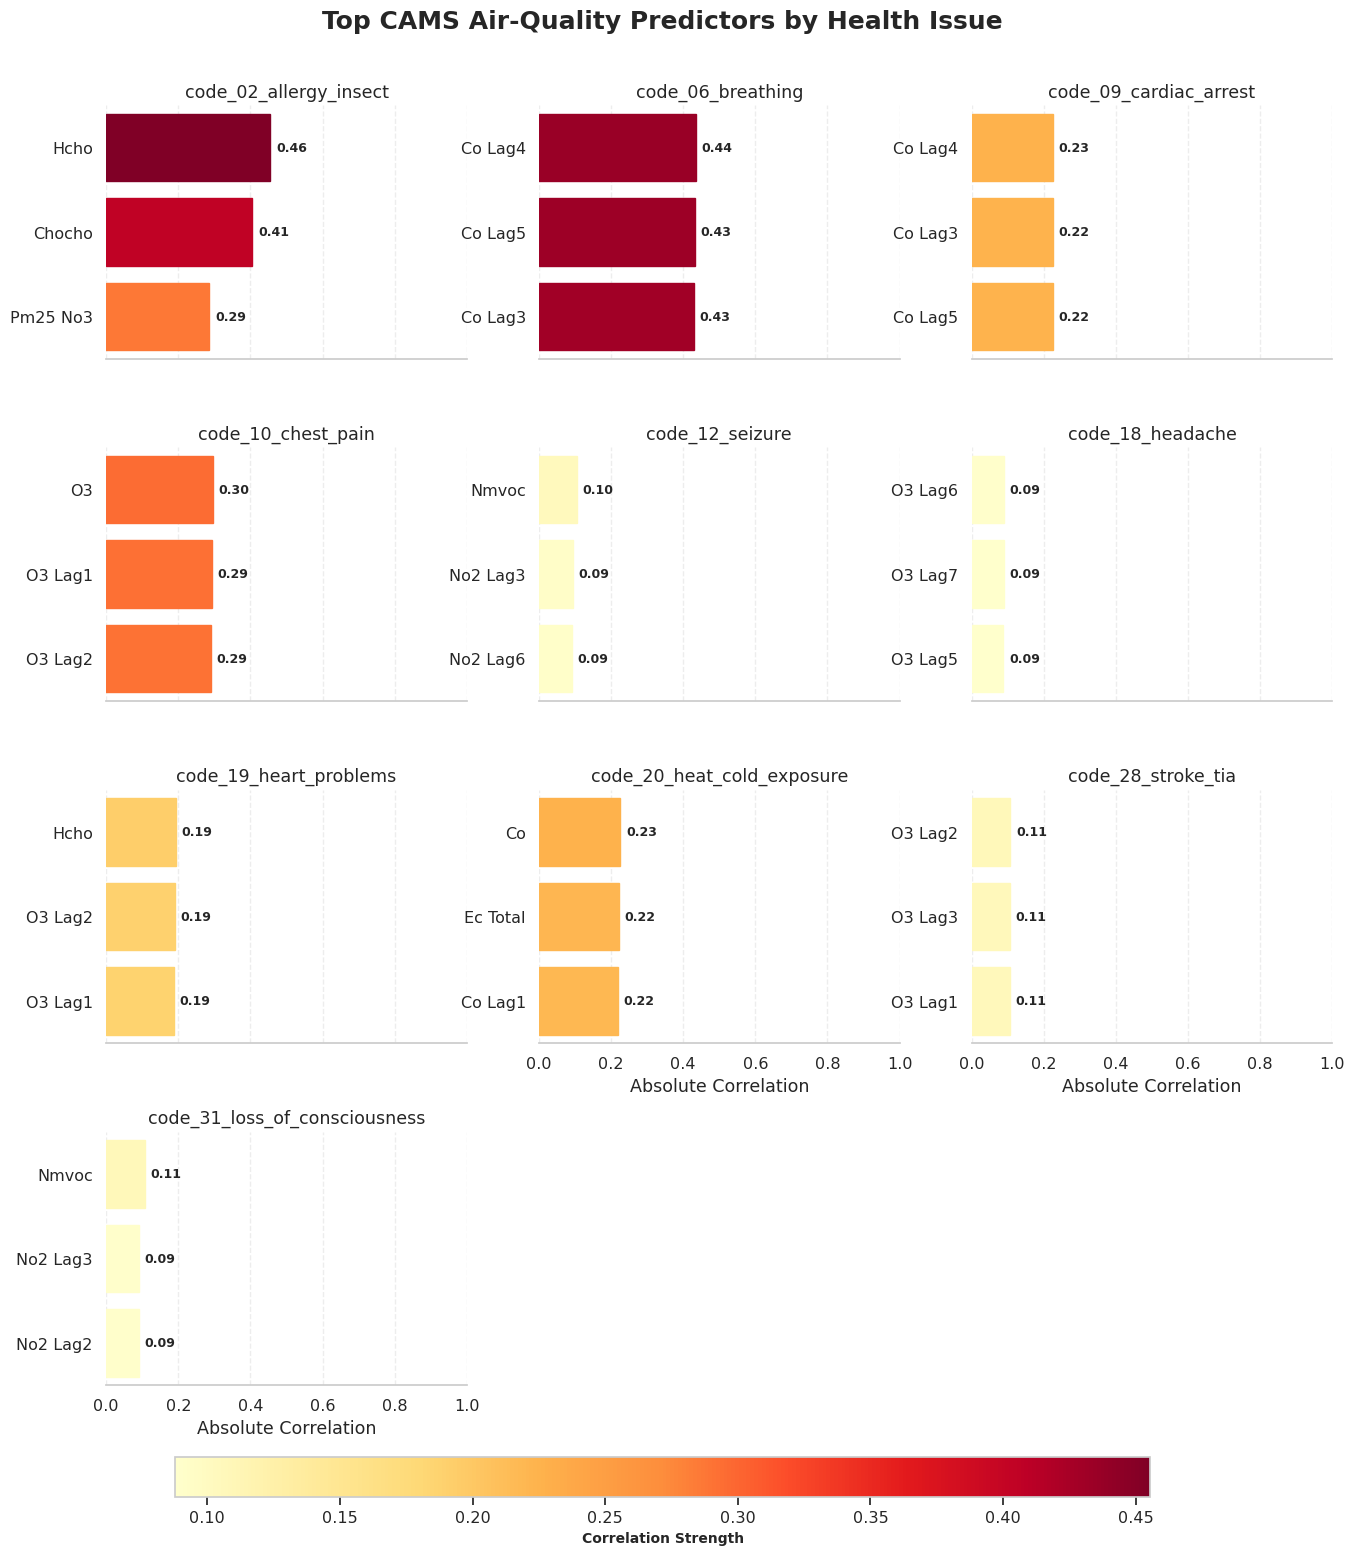

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import textwrap
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Convert correlation_results into one dataframe
plot_data = []

for health_issue, correlations in correlation_results.items():
    top_corr = correlations.head(3)

    for feature, corr_value in top_corr.items():
        plot_data.append({
            "Health Issue": health_issue,
            "CAMS Feature": feature,
            "Absolute Correlation": corr_value
        })

plot_df = pd.DataFrame(plot_data)

# Clean feature names for display
plot_df["CAMS Feature"] = (
    plot_df["CAMS Feature"]
    .str.replace("_", " ", regex=False)
    .str.replace("particulate matter 2.5um", "PM2.5", case=False, regex=False)
    .str.replace("particulate matter 10um", "PM10", case=False, regex=False)
    .str.replace("nitrogen dioxide", "NO₂", case=False, regex=False)
    .str.replace("carbon monoxide", "CO", case=False, regex=False)
    .str.replace("ozone", "O₃", case=False, regex=False)
    .str.title()
)

# Wrap long labels
plot_df["CAMS Feature Wrapped"] = plot_df["CAMS Feature"].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=22))
)

# Sort values
plot_df = plot_df.sort_values(
    ["Health Issue", "Absolute Correlation"],
    ascending=[True, False]
)

# Color normalization
norm = mcolors.Normalize(
    vmin=plot_df["Absolute Correlation"].min(),
    vmax=plot_df["Absolute Correlation"].max()
)
cmap = cm.get_cmap("YlOrRd")

sns.set_theme(style="whitegrid", font_scale=1.05)

g = sns.catplot(
    data=plot_df,
    x="Absolute Correlation",
    y="CAMS Feature Wrapped",
    col="Health Issue",
    kind="bar",
    col_wrap=3,
    height=4,
    aspect=1.15,
    sharex=True,
    sharey=False,
    color="lightgray"
)

g.set_titles("{col_name}")
g.set_axis_labels("Absolute Correlation", "")

for ax in g.axes.flatten():
    ax.set_xlim(0, 1)
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.grid(axis="y", visible=False)

    for container in ax.containers:
        for bar in container:
            corr_value = bar.get_width()
            bar.set_color(cmap(norm(corr_value)))

        ax.bar_label(
            container,
            fmt="%.2f",
            padding=4,
            fontsize=9,
            fontweight="bold"
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

# Title
g.fig.suptitle(
    "Top CAMS Air-Quality Predictors by Health Issue",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

# Add more breathing room between plots and bottom
g.fig.subplots_adjust(
    top=0.92,
    bottom=0.12,
    hspace=0.35,
    wspace=0.20
)

# Create a separate axis for the colorbar
cax = g.fig.add_axes([0.15, 0.05, 0.70, 0.025])  
# [left, bottom, width, height]

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = g.fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_label("Correlation Strength", fontsize=10, fontweight="bold")

plt.show()

In [11]:
## Join datasets on date and district
merged = pd.merge(district, ds, on=['date', 'district'], how='inner')
merged

,date,district,code_02_allergy_insect,code_06_breathing,code_09_cardiac_arrest,code_10_chest_pain,code_12_seizure,code_13_blood_sugar,code_17_falls,code_18_headache,...,nh3_lag5,nh3_lag6,nh3_lag7,dust_lag1,dust_lag2,dust_lag3,dust_lag4,dust_lag5,dust_lag6,dust_lag7
0,2025-01-01,Charlottenburg-Wilmersdorf,0.428571,15.142857,1.857143,7.428571,3.142857,0.571429,23.142857,0.142857,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,Friedrichshain-Kreuzberg,0.285714,9.857143,0.571429,6.285714,1.285714,1.000000,8.857143,0.571429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01,Lichtenberg,0.000000,12.428571,1.285714,8.428571,0.857143,0.857143,15.428571,0.857143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-01,Marzahn-Hellersdorf,0.857143,9.571429,1.571429,6.571429,2.428571,1.000000,14.285714,0.285714,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-01,Mitte,0.571429,15.000000,1.571429,9.142857,2.285714,0.714286,18.714286,0.571429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4375,2025-12-31,Reinickendorf,0.428571,13.714286,1.142857,9.142857,1.571429,1.285714,15.857143,0.714286,...,3.391076,2.036139,0.855643,0.010466,0.035160,0.031143,0.230558,0.098233,0.038996,0.042058
4376,2025-12-31,Spandau,0.857143,15.285714,1.142857,6.857143,1.714286,0.714286,15.428571,0.714286,...,2.572194,2.194589,0.880890,0.010473,0.034466,0.031344,0.228794,0.083972,0.038829,0.043074
4377,2025-12-31,Steglitz-Zehlendorf,0.857143,13.571429,2.285714,5.714286,1.857143,0.714286,20.714286,0.428571,...,2.696046,2.145082,1.086675,0.010599,0.035157,0.031734,0.231155,0.087923,0.043404,0.039825
4378,2025-12-31,Tempelhof-Schöneberg,0.571429,17.285714,1.142857,7.857143,2.428571,0.428571,18.285714,1.285714,...,4.219896,2.007176,1.038005,0.010576,0.034457,0.031506,0.235337,0.094815,0.043184,0.040034


In [12]:
df = merged.copy()


# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"])

# Extract month information
df["month"] = df["date"].dt.month

month_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

df["month_name"] = df["month"].map(month_map)
# Health issue columns
case_cols = [col for col in df.columns if col.startswith("code_")]

df_long = df.melt(
    id_vars=["date", "district", "month", "month_name"],
    value_vars=case_cols,
    var_name="health_issue",
    value_name="case_count"
)

# for health_issue in df_long["health_issue"].unique():
#     selected_issue = health_issue

#     plot_df = df_long[df_long["health_issue"] == selected_issue]

#     sns.set_theme(style="whitegrid", font_scale=1.0)

#     g = sns.relplot(
#         data=plot_df,
#         x="date",
#         y="case_count",
#         col="district",
#         col_wrap=3,
#         kind="line",
#         marker="o",
#         height=3.2,
#         aspect=1.4,
#         linewidth=1.8,
#         facet_kws={"sharey": False}
#     )

#     g.set_titles("{col_name}")
#     g.set_axis_labels("Date", "Cases")

#     for ax in g.axes.flatten():
#         ax.tick_params(axis="x", rotation=45)
#         ax.grid(axis="y", linestyle="--", alpha=0.35)
#         ax.grid(axis="x", visible=False)

#     plt.suptitle(
#         f"District-wise Timeseries Progression: {selected_issue}",
#         fontsize=18,
#         fontweight="bold",
#         y=1.03
#     )

#     plt.tight_layout()
#     plt.show()

In [13]:
monthly_cases = (
    df_long
    .groupby(["month", "month_name", "health_issue"], as_index=False)
    ["case_count"]
    .mean()
)

monthly_cases

,month,month_name,health_issue,case_count
0,1,Jan,code_02_allergy_insect,0.621352
1,1,Jan,code_06_breathing,13.855991
2,1,Jan,code_09_cardiac_arrest,1.348694
3,1,Jan,code_10_chest_pain,7.521505
4,1,Jan,code_12_seizure,2.572965
...,...,...,...,...
139,12,Dec,code_18_headache,1.064132
140,12,Dec,code_19_heart_problems,5.711214
141,12,Dec,code_20_heat_cold_exposure,0.213518
142,12,Dec,code_28_stroke_tia,3.805300


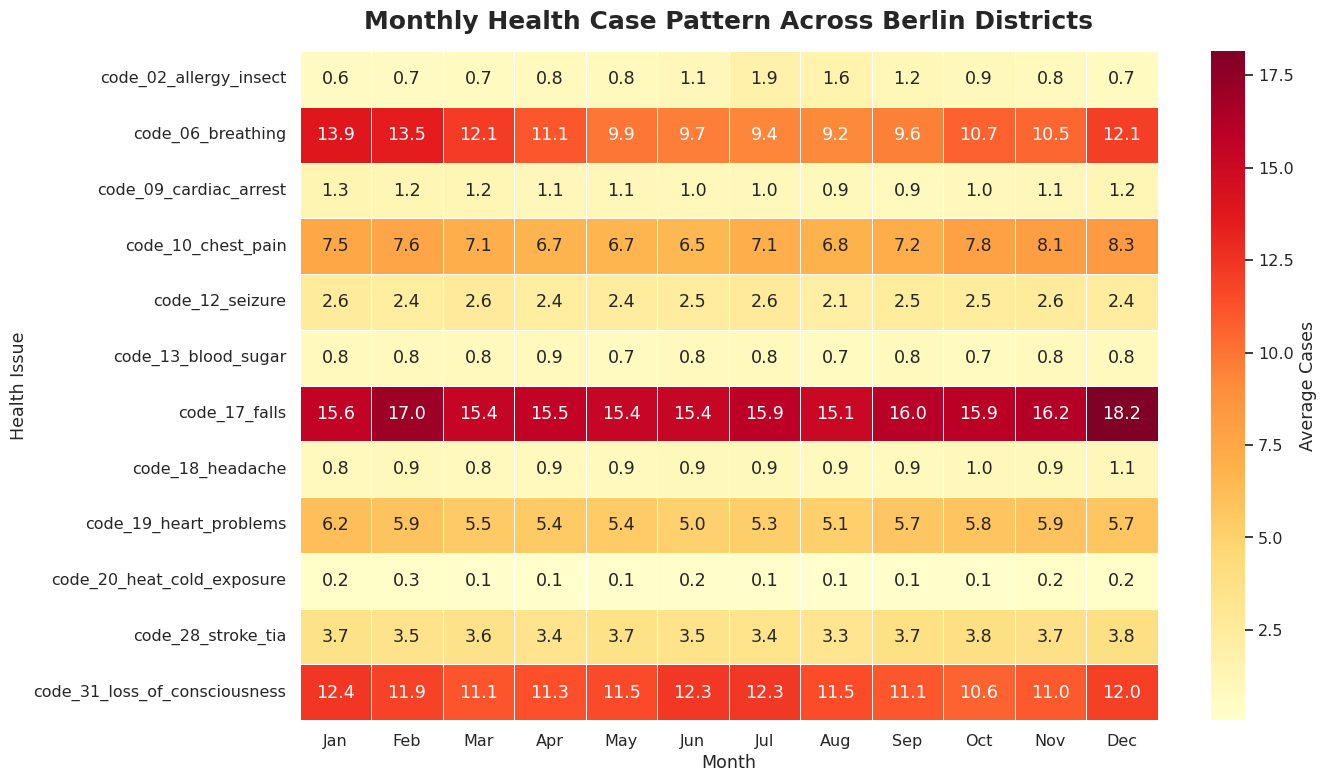

In [14]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_matrix = monthly_cases.pivot(
    index="health_issue",
    columns="month_name",
    values="case_count"
)

monthly_matrix = monthly_matrix.reindex(columns=month_order)

plt.figure(figsize=(14, 8))

sns.heatmap(
    monthly_matrix,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Average Cases"}
)

plt.title(
    "Monthly Health Case Pattern Across Berlin Districts",
    fontsize=18,
    fontweight="bold",
    pad=16
)

plt.xlabel("Month")
plt.ylabel("Health Issue")

plt.tight_layout()
plt.show()

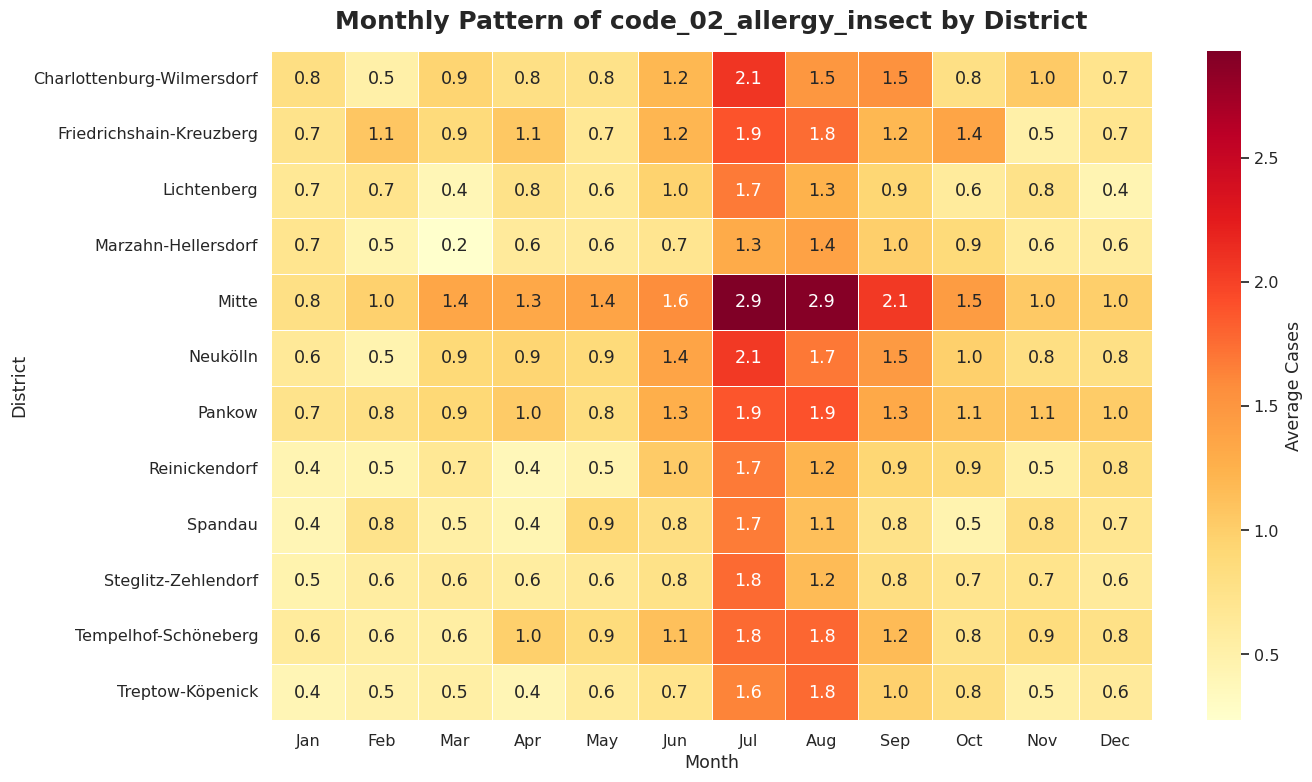

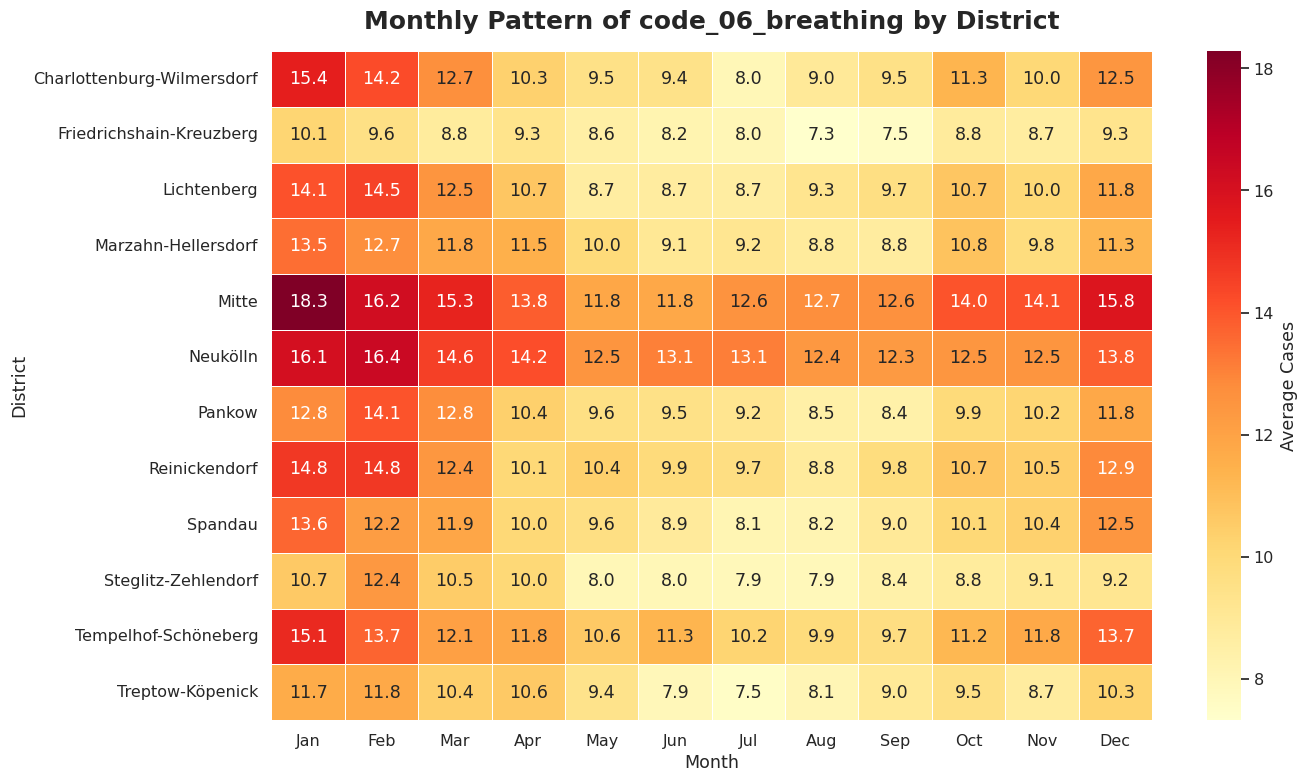

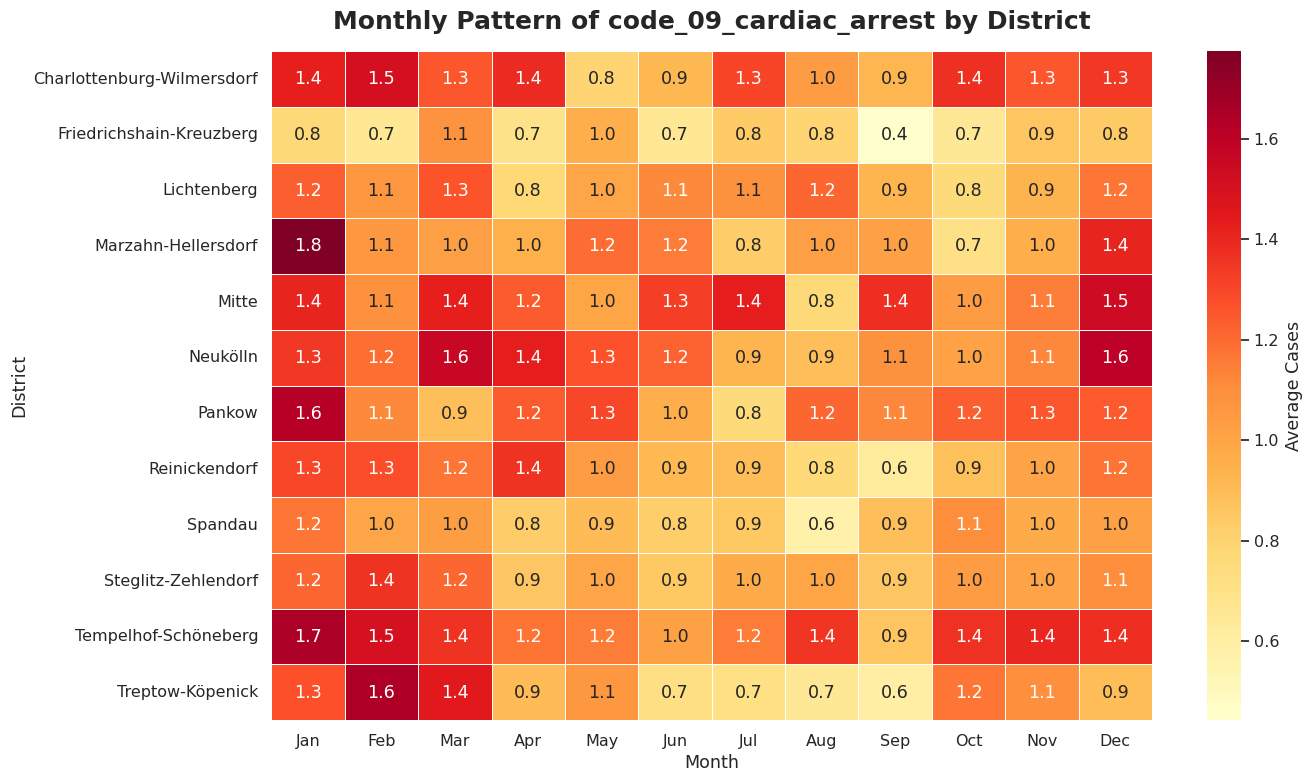

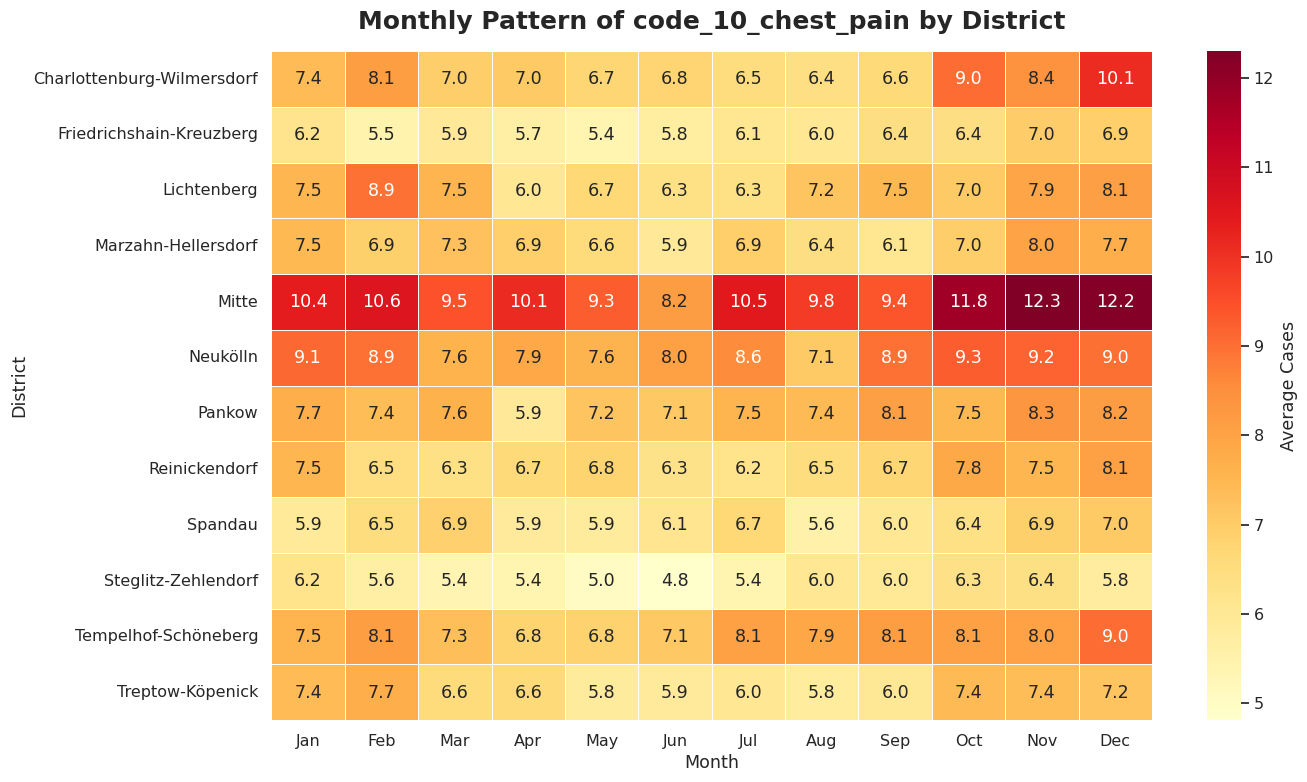

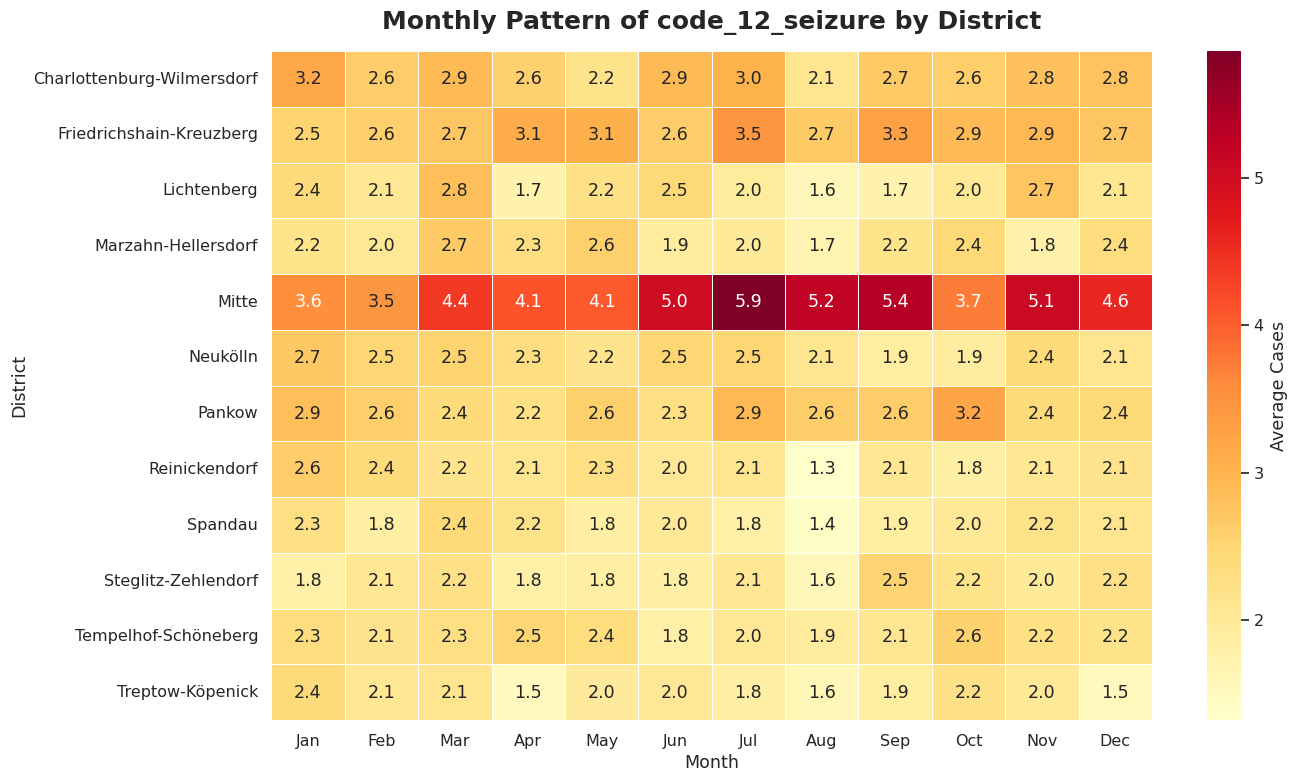

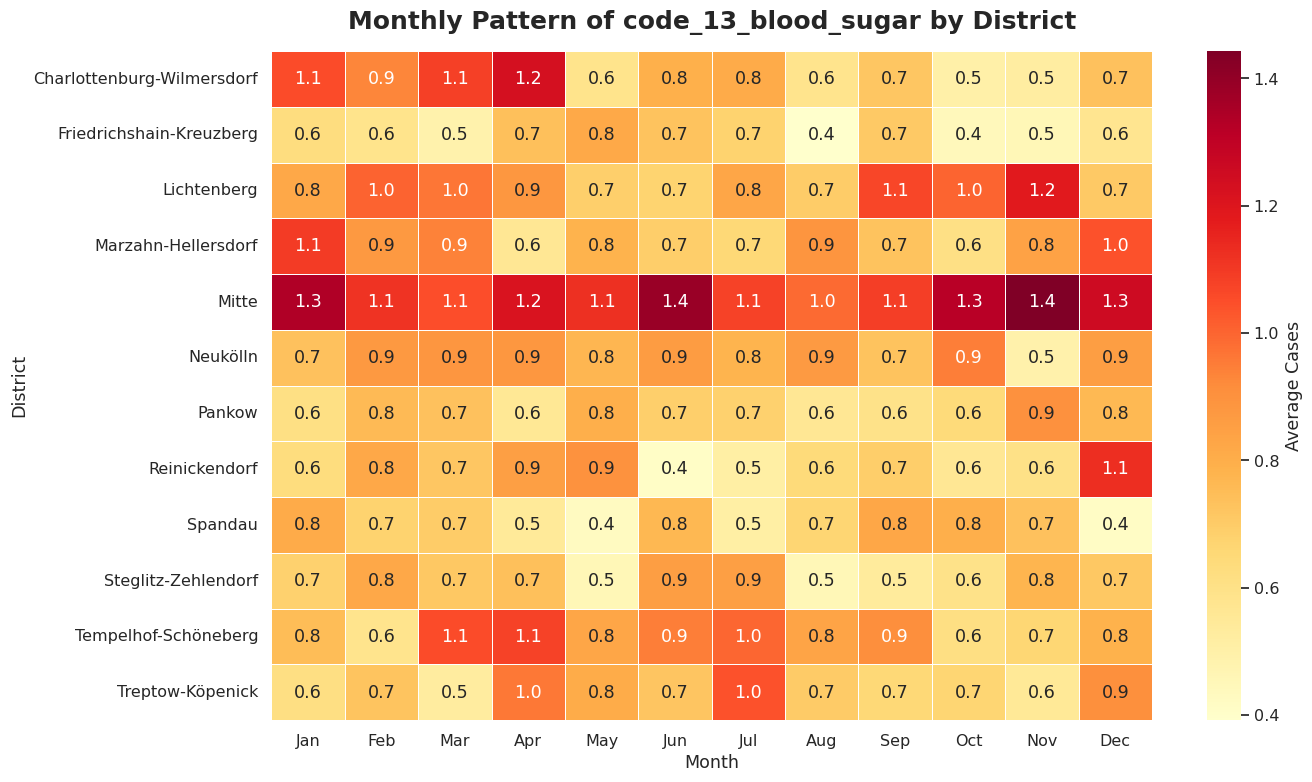

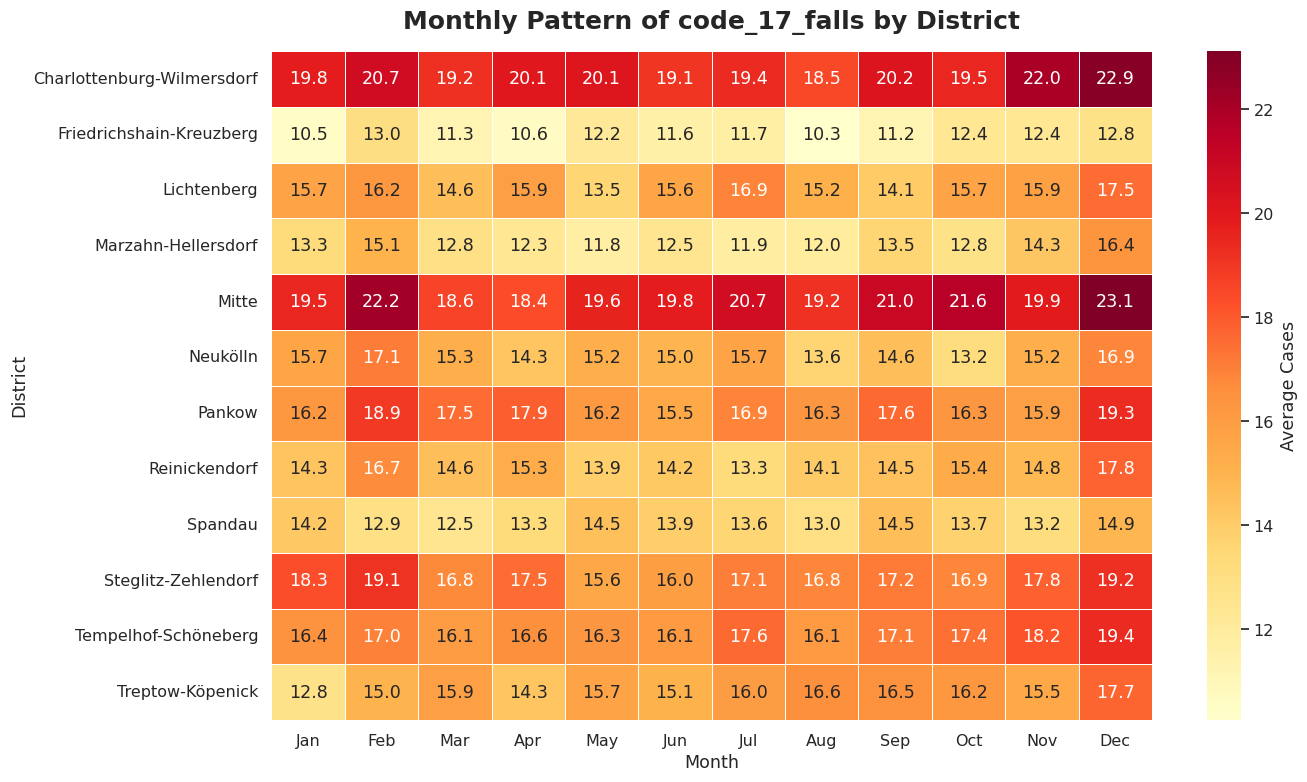

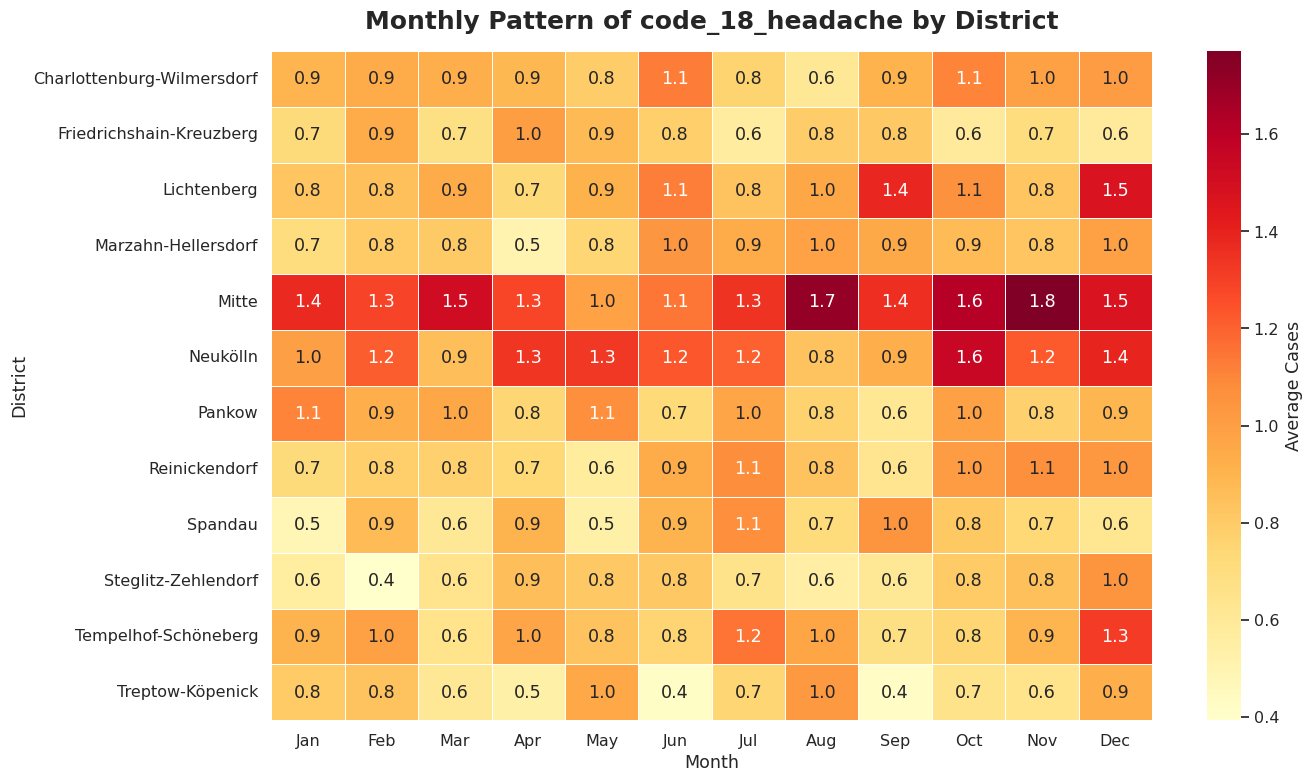

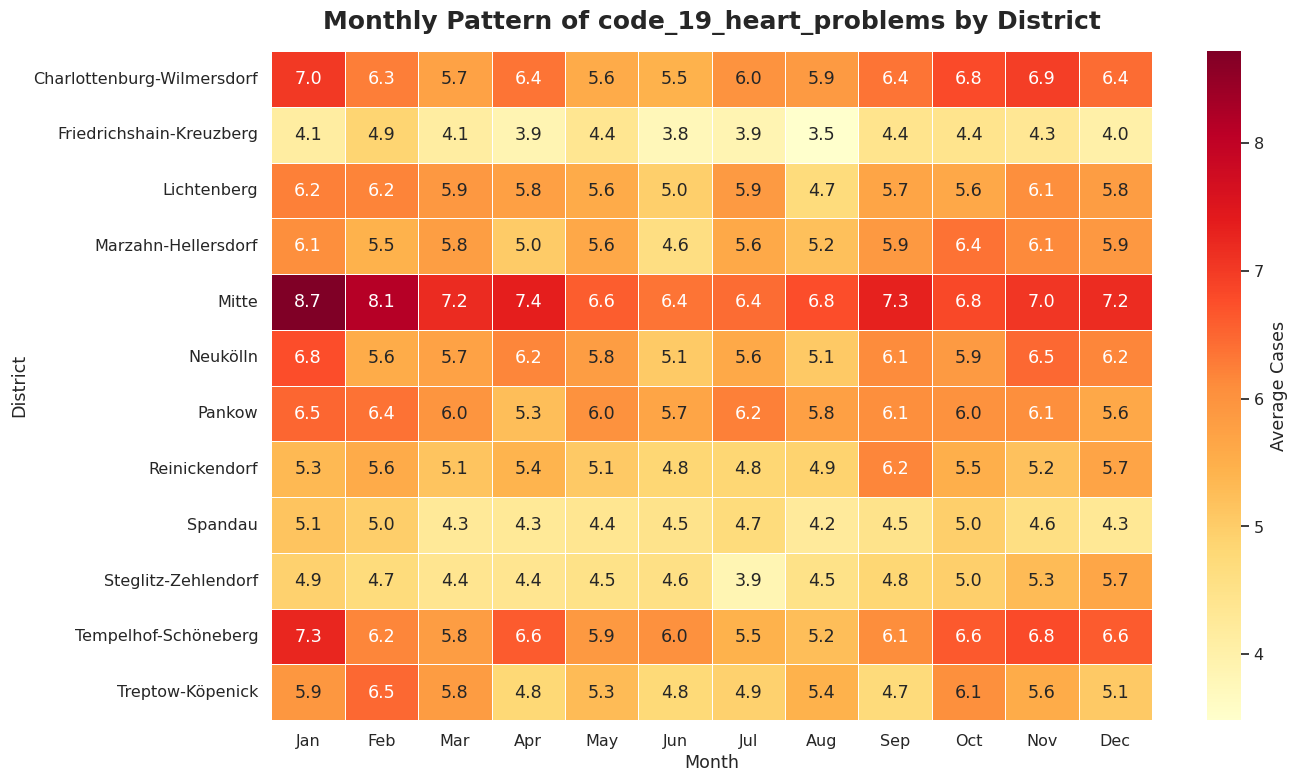

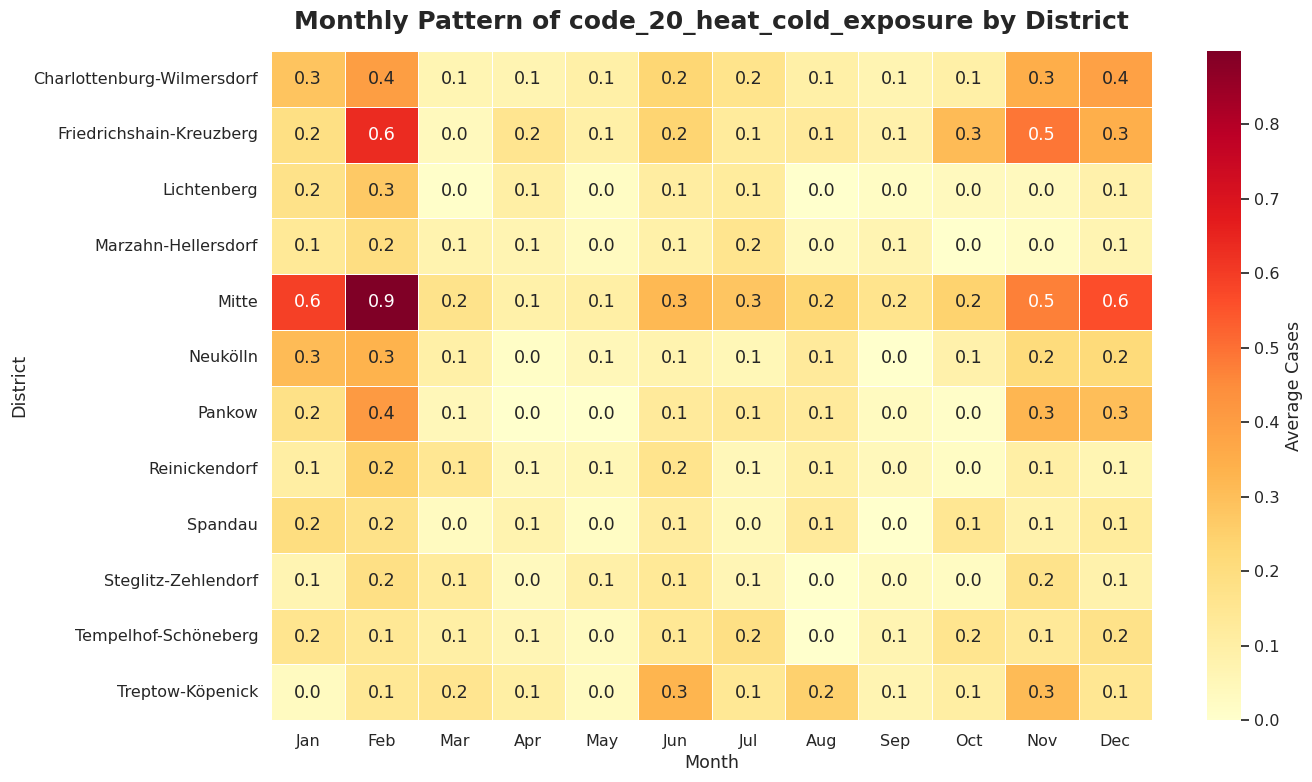

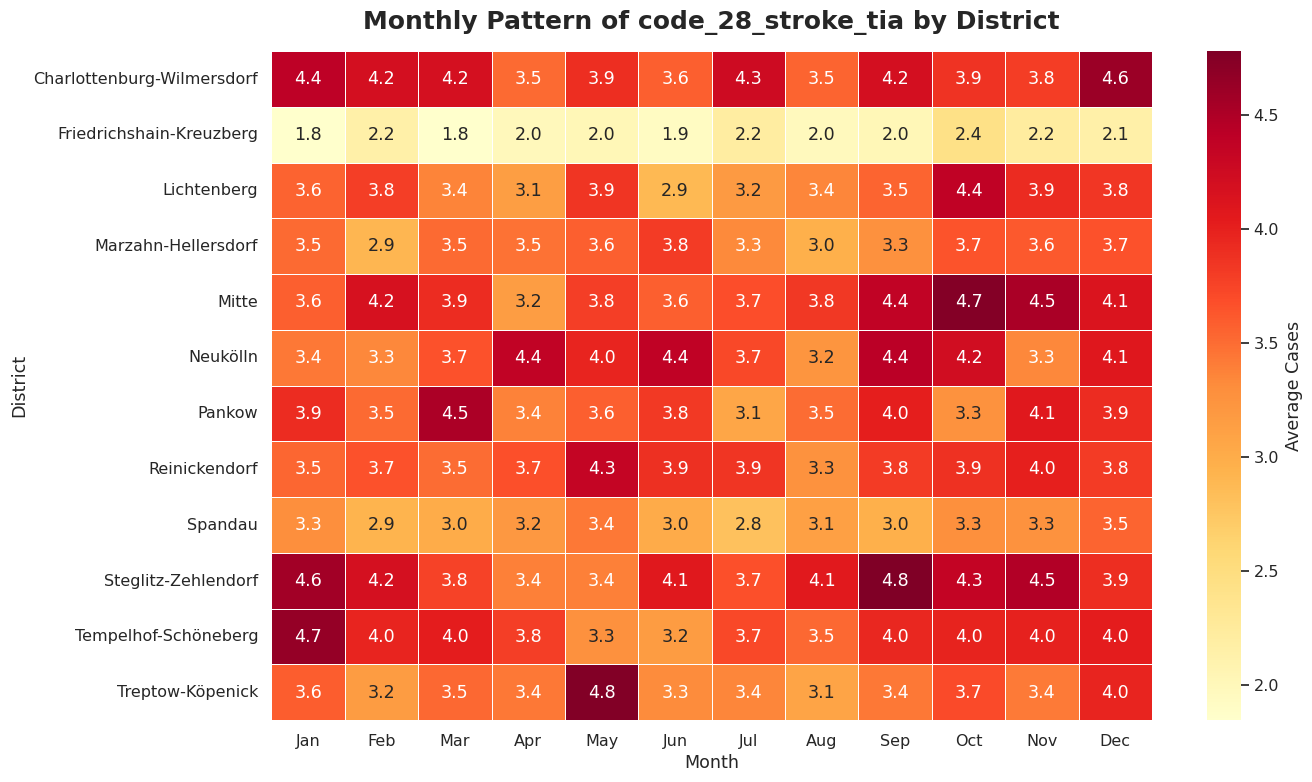

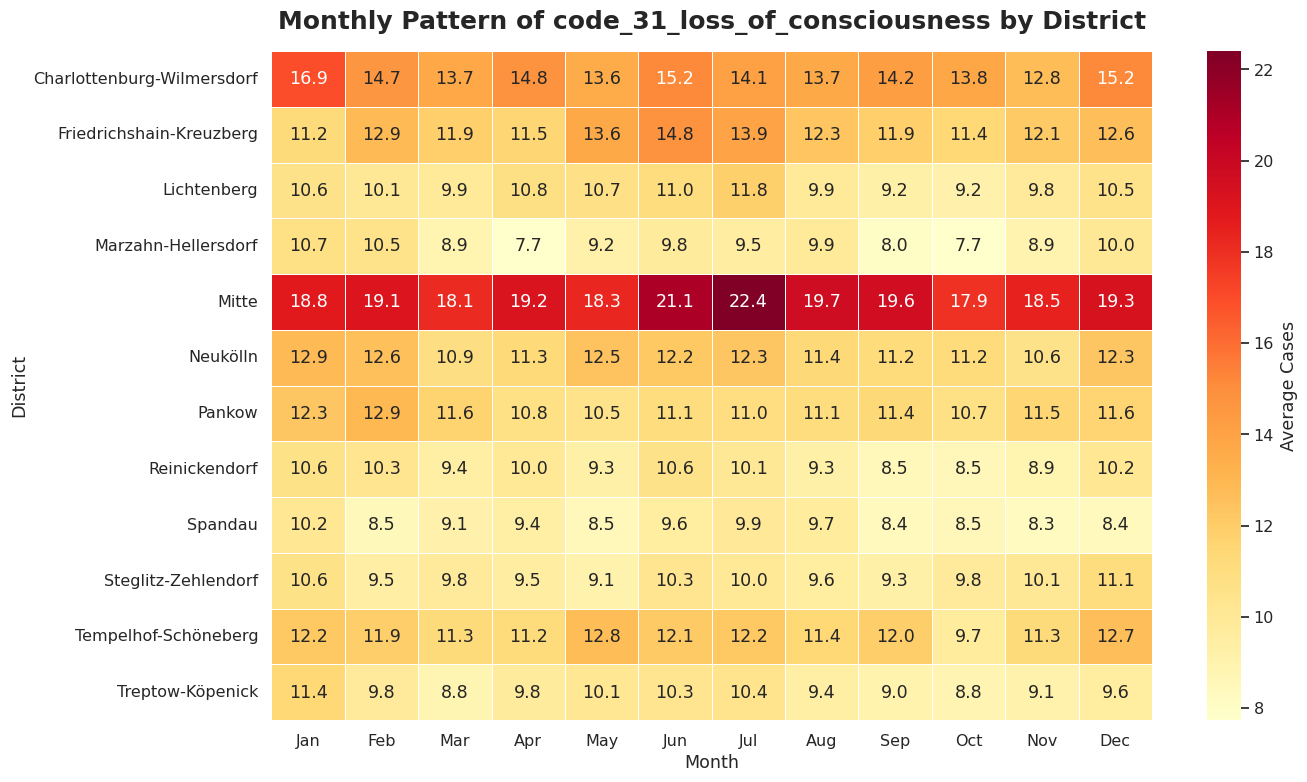

In [15]:
for selected_issue in df_long["health_issue"].unique():

    district_monthly = (
        df_long[df_long["health_issue"] == selected_issue]
        .groupby(["district", "month_name"], as_index=False)
        ["case_count"]
        .mean()
    )

    district_monthly_matrix = district_monthly.pivot(
        index="district",
        columns="month_name",
        values="case_count"
    )

    district_monthly_matrix = district_monthly_matrix.reindex(columns=month_order)

    plt.figure(figsize=(14, 8))

    sns.heatmap(
        district_monthly_matrix,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        linewidths=0.6,
        linecolor="white",
        cbar_kws={"label": "Average Cases"}
    )

    plt.title(
        f"Monthly Pattern of {selected_issue} by District",
        fontsize=18,
        fontweight="bold",
        pad=16
    )

    plt.xlabel("Month")
    plt.ylabel("District")

    plt.tight_layout()
    plt.show()